# NB7: Combined Feature Analysis (Old + New Descriptors)

**Goal:** Merge best features from old nb6 (point-based) and new nb6 (plane-based),
define feature combinations ensuring proven features are included, and test each on:

| | Regression (LOO R2) | Classification (LOO F1, threshold 1.5) |
|---|---|---|
| **205 rows** | GroupLeaveOneOut by uid | GroupLeaveOneOut by uid |
| **99 rows** | Standard LOO | Standard LOO |

**Location:** `Keshav-DDP/k-path/old+new_nb6/nb7_combined_analysis.ipynb`

## Cell 1: Configuration

In [1]:
import os

# =============================================================================
# PATHS -- CHANGE THESE IF YOU MOVE THE NOTEBOOK
# =============================================================================
BASE_DIR = os.path.abspath(os.path.join("..", ".."))

# Old nb6 CSV (point-based descriptors, 205 rows)
OLD_CSV = os.path.join(
    BASE_DIR, "k-path", "old+new_nb6",
    "rashba_206_all_descriptors_old.csv"
)

# New nb6 CSV (plane-based descriptors, 205 rows)
NEW_CSV = os.path.join(
    BASE_DIR, "k-path", "old+new_nb6",
    "rashba_206_all_descriptors.csv"
)

RESULTS_DIR = os.path.join(".", "nb7_combined-results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# =============================================================================
print("=" * 65)
print("  PATH CONFIGURATION")
print("=" * 65)
for name, path in [("BASE_DIR", BASE_DIR), ("OLD_CSV", OLD_CSV),
                    ("NEW_CSV", NEW_CSV), ("RESULTS_DIR", RESULTS_DIR)]:
    exists = os.path.exists(path)
    status = "OK" if exists else "MISSING"
    print(f"  [{status:7s}] {name:15s} = {path}")

  PATH CONFIGURATION
  [OK     ] BASE_DIR        = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP
  [OK     ] OLD_CSV         = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\k-path\old+new_nb6\rashba_206_all_descriptors_old.csv
  [OK     ] NEW_CSV         = c:\Users\AbCMS_Lab\Desktop\Keshav-DDP\k-path\old+new_nb6\rashba_206_all_descriptors.csv
  [OK     ] RESULTS_DIR     = .\nb7_combined-results


## Cell 2: Imports

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from time import time
import seaborn as sns

from sklearn.model_selection import (
    LeaveOneOut, LeaveOneGroupOut, GroupKFold,
    cross_val_score, cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score, mean_absolute_error, f1_score, roc_auc_score,
    accuracy_score, precision_score, recall_score
)
from xgboost import XGBRegressor, XGBClassifier

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

print("Imports OK.")

Imports OK.


## Cell 3: Load and merge CSVs

In [3]:
df_old = pd.read_csv(OLD_CSV)
df_new = pd.read_csv(NEW_CSV)

print(f"Old CSV: {df_old.shape[0]} rows, {df_old.shape[1]} columns")
print(f"New CSV: {df_new.shape[0]} rows, {df_new.shape[1]} columns")

ID_COLS = ['Formula', 'uid', 'kpath', 'Rashba_parameter']
TARGET = 'Rashba_parameter'

# Merge: add all features from both, prefix overlapping names
df_merged = df_old[ID_COLS].copy()

old_features = [c for c in df_old.columns if c not in ID_COLS]
new_features = [c for c in df_new.columns if c not in ID_COLS]
overlap = set(old_features) & set(new_features)

print(f"Overlapping feature names: {len(overlap)}")

for col in old_features:
    new_name = f"old_{col}" if col in overlap else col
    df_merged[new_name] = df_old[col].values

for col in new_features:
    new_name = f"new_{col}" if col in overlap else col
    if new_name not in df_merged.columns:
        df_merged[new_name] = df_new[col].values

print(f"Merged: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")

Old CSV: 205 rows, 1263 columns
New CSV: 205 rows, 134 columns
Overlapping feature names: 27
Merged: 205 rows, 1393 columns


## Cell 4: Define feature combinations

**Proven important features from all stages:**
- E_pfrac_VBM, E_pfrac_CBM (DOS, Stage 1-2)
- radius_mean (+0.184 R2 boost, Stage 2)
- max_Z4 (Z^4 ~ SOC strength, best classification combo)
- max_Z (in best classification combo)
- pmid_afs_gauss_std (best new plane feature)
- pmid_grdf_trig_max (dominated new nb6 pairs)
- kpath_angle_deg (k-path geometry)
- ehull (stability, helped in new nb6)

In [4]:
all_cols = set(df_merged.columns)


def resolve_features(feat_list):
    """Resolve feature names: try original, then old_, then new_ prefix."""
    resolved = []
    missing = []
    for f in feat_list:
        if f in all_cols:
            resolved.append(f)
        elif f"old_{f}" in all_cols:
            resolved.append(f"old_{f}")
        elif f"new_{f}" in all_cols:
            resolved.append(f"new_{f}")
        else:
            missing.append(f)
    if missing:
        print(f"    WARNING missing: {missing}")
    return resolved


def swap_epfrac_for_99(features, df_cols):
    """
    For 99-row evaluation:
    - Replace E_pfrac_relevant -> E_pfrac_VBM + E_pfrac_CBM
    - Drop band_binary (meaningless for single-row-per-compound)
    """
    new_feats = []
    added_vbm_cbm = False

    for f in features:
        if 'E_pfrac_relevant' in f:
            if not added_vbm_cbm:
                for c in ['E_pfrac_VBM', 'old_E_pfrac_VBM', 'new_E_pfrac_VBM']:
                    if c in df_cols:
                        new_feats.append(c)
                        break
                for c in ['E_pfrac_CBM', 'old_E_pfrac_CBM', 'new_E_pfrac_CBM']:
                    if c in df_cols:
                        new_feats.append(c)
                        break
                added_vbm_cbm = True
        elif 'band_binary' in f:
            continue
        else:
            new_feats.append(f)
    return new_feats


# ============================================================
# COMBO DEFINITIONS
# ============================================================
# Ensuring radius_mean and max_Z4 are included in key combos

COMBOS = {
    # --- Small combos (3-4 features) ---
    "C1_stage2_original": [
        "E_pfrac_relevant", "radius_mean",
    ],  # Will become VBM + CBM + radius_mean on 99 rows (the 0.563 baseline)

    "C2_new_best4": [
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg",
    ],

    "C3_old_best4": [
        "E_pfrac_relevant", "start_adf_min", "start_adf_n_triplets", "mid_nearest_Z",
    ],

    # --- Medium combos (5-7 features, the sweet spot for 99 rows) ---
    "C4_new4_plus_rm": [
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg", "radius_mean",
    ],

    "C5_new4_rm_Z4": [
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg",
        "radius_mean", "max_Z4",
    ],

    "C6_proven_plus_new": [
        "E_pfrac_relevant", "radius_mean", "max_Z4",
        "pmid_afs_gauss_std", "kpath_angle_deg", "ehull",
    ],  # All proven features + top new features

    "C7_old_best7": [
        "E_pfrac_relevant", "mid_adf_n_triplets", "start_adf_min",
        "mid_nearest_Z", "start_adf_mean", "kpath_angle_deg", "mid_nearest_Z4",
    ],

    "C8_old7_plus_rm": [
        "E_pfrac_relevant", "mid_adf_n_triplets", "start_adf_min",
        "mid_nearest_Z", "start_adf_mean", "kpath_angle_deg", "mid_nearest_Z4",
        "radius_mean",
    ],

    "C9_new_best7": [
        "pmid_grdf_trig_max", "E_pfrac_relevant", "E_pfrac_CBM",
        "radius_mean", "pmid_grdf_gauss_std", "kstart_frac_x", "pmid_afs_trig_mean",
    ],

    # --- Larger combos (8-10 features) ---
    "C10_balanced_all_proven": [
        "E_pfrac_relevant", "radius_mean", "max_Z4", "max_Z",
        "pmid_afs_gauss_std", "pmid_grdf_trig_max", "kpath_angle_deg", "ehull",
    ],  # All proven + all best new

    "C11_full_mix": [
        "E_pfrac_relevant", "radius_mean", "max_Z4", "max_Z",
        "pmid_afs_gauss_std", "pmid_grdf_trig_max", "kpath_angle_deg", "ehull",
        "mid_nearest_Z", "pstart_afs_gauss_std",
    ],

    "C12_balanced_plus_band": [
        "E_pfrac_relevant", "radius_mean", "max_Z4",
        "pmid_afs_gauss_std", "pmid_grdf_trig_max", "kpath_angle_deg", "ehull",
        "band_binary",
    ],

    # --- Kitchen sink (12-15+) ---
    "C13_kitchen_sink": [
        "E_pfrac_relevant", "E_pfrac_CBM", "radius_mean", "max_Z4", "max_Z",
        "mid_adf_n_triplets", "start_adf_min", "mid_nearest_Z", "start_adf_mean",
        "mid_nearest_Z4", "pmid_grdf_trig_max", "ehull", "pmid_afs_gauss_std",
        "pstart_afs_gauss_std", "kpath_angle_deg",
    ],

    "C14_everything": [
        "E_pfrac_relevant", "E_pfrac_CBM", "radius_mean", "ehull",
        "max_Z4", "max_Z", "n_elements", "sum_Z4",
        "mid_nearest_Z", "mid_nearest_Z4",
        "kpath_angle_deg", "band_binary", "kstart_frac_y", "kend_frac_x", "kvec_z",
        "pmid_grdf_trig_max", "pend_grdf_trig_max", "pmid_afs_gauss_std",
        "pstart_afs_gauss_std", "pstart_afs_bessel_std", "pmid_grdf_gauss_std",
        "start_adf_min", "start_adf_mean", "mid_adf_n_triplets", "mid_adf_max",
    ],
}

# Resolve
print("Resolving feature names:\n")
RESOLVED_COMBOS = {}
for name, feats in COMBOS.items():
    resolved = resolve_features(feats)
    RESOLVED_COMBOS[name] = resolved
    feats_99 = swap_epfrac_for_99(resolved, set(df_merged.columns))
    print(f"  {name}: {len(resolved)} feat (205) / {len(feats_99)} feat (99)")

Resolving feature names:

  C1_stage2_original: 2 feat (205) / 3 feat (99)
  C2_new_best4: 4 feat (205) / 5 feat (99)
  C3_old_best4: 4 feat (205) / 5 feat (99)
  C4_new4_plus_rm: 5 feat (205) / 6 feat (99)
  C5_new4_rm_Z4: 6 feat (205) / 7 feat (99)
  C6_proven_plus_new: 6 feat (205) / 7 feat (99)
  C7_old_best7: 7 feat (205) / 8 feat (99)
  C8_old7_plus_rm: 8 feat (205) / 9 feat (99)
  C9_new_best7: 7 feat (205) / 8 feat (99)
  C10_balanced_all_proven: 8 feat (205) / 9 feat (99)
  C11_full_mix: 10 feat (205) / 11 feat (99)
  C12_balanced_plus_band: 8 feat (205) / 8 feat (99)
  C13_kitchen_sink: 15 feat (205) / 16 feat (99)
  C14_everything: 25 feat (205) / 25 feat (99)


## Cell 5: Prepare datasets

In [5]:
y_205 = df_merged[TARGET].values
groups_205 = df_merged['uid'].values

# 99-row: max alpha_R per uid
idx_99 = df_merged.groupby('uid')[TARGET].idxmax()
df_99 = df_merged.loc[idx_99].reset_index(drop=True)
y_99 = df_99[TARGET].values

THRESHOLD = 1.5
y_class_205 = (y_205 >= THRESHOLD).astype(int)
y_class_99 = (y_99 >= THRESHOLD).astype(int)

print(f"205 rows: {len(y_205)} rows, {len(np.unique(groups_205))} compounds")
print(f"99 rows:  {len(y_99)} rows")
print(f"Classification (t={THRESHOLD}): 205={y_class_205.sum()}+/{len(y_class_205)-y_class_205.sum()}-  "
      f"99={y_class_99.sum()}+/{len(y_class_99)-y_class_99.sum()}-")

205 rows: 205 rows, 99 compounds
99 rows:  99 rows
Classification (t=1.5): 205=89+/116-  99=50+/49-


## Cell 6: Model configs

In [6]:
XGB_REG_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    random_state=42, verbosity=0
)

XGB_CLF_PARAMS = dict(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0,
    scale_pos_weight=3,
    eval_metric='logloss', use_label_encoder=False,
    random_state=42, verbosity=0
)

## Cell 7: Evaluation functions

In [7]:
def eval_reg_205(features):
    X = df_merged[features].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    y_pred = cross_val_predict(model, X, y_205, cv=LeaveOneGroupOut(), groups=groups_205)
    return r2_score(y_205, y_pred), mean_absolute_error(y_205, y_pred)

def eval_reg_99(features):
    feats_99 = swap_epfrac_for_99(features, set(df_99.columns))
    X = df_99[feats_99].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
    return r2_score(y_99, y_pred), mean_absolute_error(y_99, y_pred), feats_99

def eval_clf_205(features):
    X = df_merged[features].fillna(0).values
    model = XGBClassifier(**XGB_CLF_PARAMS)
    logo = LeaveOneGroupOut()
    y_pred = cross_val_predict(model, X, y_class_205, cv=logo, groups=groups_205)
    try:
        y_prob = cross_val_predict(model, X, y_class_205, cv=logo, groups=groups_205, method='predict_proba')[:, 1]
        auc = roc_auc_score(y_class_205, y_prob)
    except:
        auc = np.nan
    return f1_score(y_class_205, y_pred), auc, precision_score(y_class_205, y_pred, zero_division=0), recall_score(y_class_205, y_pred, zero_division=0)

def eval_clf_99(features):
    feats_99 = swap_epfrac_for_99(features, set(df_99.columns))
    X = df_99[feats_99].fillna(0).values
    model = XGBClassifier(**XGB_CLF_PARAMS)
    y_pred = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut())
    try:
        y_prob = cross_val_predict(model, X, y_class_99, cv=LeaveOneOut(), method='predict_proba')[:, 1]
        auc = roc_auc_score(y_class_99, y_prob)
    except:
        auc = np.nan
    return f1_score(y_class_99, y_pred), auc, precision_score(y_class_99, y_pred, zero_division=0), recall_score(y_class_99, y_pred, zero_division=0)

print("Evaluation functions defined.")

Evaluation functions defined.


## Cell 8: RUN ALL COMBOS x 4 SCENARIOS

In [8]:
print("=" * 80)
print(f"  RUNNING {len(RESOLVED_COMBOS)} COMBOS x 4 SCENARIOS")
print("=" * 80)

all_results = []

for combo_name, features in RESOLVED_COMBOS.items():
    if not features:
        continue

    print(f"\n  {combo_name} ({len(features)} feat)...", end=" ", flush=True)
    t0 = time()
    result = {'combo': combo_name, 'n_feat': len(features), 'features': ', '.join(features)}

    # 1. Regression 205
    try:
        r2, mae = eval_reg_205(features)
        result['reg205_r2'] = r2
        result['reg205_mae'] = mae
    except Exception as e:
        result['reg205_r2'] = np.nan; result['reg205_mae'] = np.nan

    # 2. Regression 99
    try:
        r2, mae, feats_99 = eval_reg_99(features)
        result['reg99_r2'] = r2
        result['reg99_mae'] = mae
        result['n_feat_99'] = len(feats_99)
        result['features_99'] = ', '.join(feats_99)
    except Exception as e:
        result['reg99_r2'] = np.nan; result['reg99_mae'] = np.nan

    # 3. Classification 205
    try:
        f1, auc, prec, rec = eval_clf_205(features)
        result['clf205_f1'] = f1; result['clf205_auc'] = auc
        result['clf205_prec'] = prec; result['clf205_rec'] = rec
    except:
        result['clf205_f1'] = np.nan; result['clf205_auc'] = np.nan

    # 4. Classification 99
    try:
        f1, auc, prec, rec = eval_clf_99(features)
        result['clf99_f1'] = f1; result['clf99_auc'] = auc
        result['clf99_prec'] = prec; result['clf99_rec'] = rec
    except:
        result['clf99_f1'] = np.nan; result['clf99_auc'] = np.nan

    elapsed = time() - t0
    print(f"R2_99={result.get('reg99_r2', np.nan):.4f}, F1_99={result.get('clf99_f1', np.nan):.4f} ({elapsed:.1f}s)")

    all_results.append(result)

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "all_results.csv"), index=False)

  RUNNING 14 COMBOS x 4 SCENARIOS

  C1_stage2_original (2 feat)... R2_99=0.5634, F1_99=0.8000 (15.6s)

  C2_new_best4 (4 feat)... R2_99=0.5778, F1_99=0.8000 (16.0s)

  C3_old_best4 (4 feat)... R2_99=0.5483, F1_99=0.7963 (14.6s)

  C4_new4_plus_rm (5 feat)... R2_99=0.5970, F1_99=0.8113 (14.7s)

  C5_new4_rm_Z4 (6 feat)... R2_99=0.5979, F1_99=0.8000 (14.5s)

  C6_proven_plus_new (6 feat)... R2_99=0.6320, F1_99=0.8073 (14.5s)

  C7_old_best7 (7 feat)... R2_99=0.5496, F1_99=0.8182 (15.0s)

  C8_old7_plus_rm (8 feat)... R2_99=0.5752, F1_99=0.7778 (17.7s)

  C9_new_best7 (7 feat)... R2_99=0.4878, F1_99=0.8598 (15.0s)

  C10_balanced_all_proven (8 feat)... R2_99=0.6021, F1_99=0.8148 (14.5s)

  C11_full_mix (10 feat)... R2_99=0.5549, F1_99=0.8333 (14.8s)

  C12_balanced_plus_band (8 feat)... R2_99=0.5590, F1_99=0.8411 (14.7s)

  C13_kitchen_sink (15 feat)... R2_99=0.5645, F1_99=0.7890 (15.4s)

  C14_everything (25 feat)... R2_99=0.5254, F1_99=0.8269 (16.5s)


## Cell 9: Summary tables

In [9]:
print("=" * 80)
print("  REGRESSION RESULTS (sorted by 99-row LOO R2)")
print("=" * 80)
reg_cols = ['combo', 'n_feat', 'n_feat_99', 'reg205_r2', 'reg99_r2', 'reg99_mae']
print(results_df[reg_cols].sort_values('reg99_r2', ascending=False).to_string(index=False))

print(f"\n{'='*80}")
print("  CLASSIFICATION RESULTS (sorted by 99-row LOO F1)")
print("=" * 80)
clf_cols = ['combo', 'n_feat', 'clf205_f1', 'clf205_auc', 'clf99_f1', 'clf99_auc', 'clf99_prec', 'clf99_rec']
print(results_df[clf_cols].sort_values('clf99_f1', ascending=False).to_string(index=False))

print(f"\nReference (previous best):")
print(f"  Regression 99:     R2 = 0.563 (3 feat)")
print(f"  Classification 99: F1 = 0.849, AUC = 0.907 (5 feat)")

  REGRESSION RESULTS (sorted by 99-row LOO R2)
                  combo  n_feat  n_feat_99  reg205_r2  reg99_r2  reg99_mae
     C6_proven_plus_new       6          7   0.461583  0.631983   0.428356
C10_balanced_all_proven       8          9   0.461486  0.602110   0.422795
          C5_new4_rm_Z4       6          7   0.474084  0.597947   0.438492
        C4_new4_plus_rm       5          6   0.471148  0.596975   0.452216
           C2_new_best4       4          5   0.511592  0.577831   0.452470
        C8_old7_plus_rm       8          9   0.430043  0.575163   0.459317
       C13_kitchen_sink      15         16   0.465063  0.564454   0.458230
     C1_stage2_original       2          3   0.118467  0.563368   0.478718
 C12_balanced_plus_band       8          8   0.515087  0.559009   0.463297
           C11_full_mix      10         11   0.462818  0.554927   0.459616
           C7_old_best7       7          8   0.449421  0.549584   0.467197
           C3_old_best4       4          5   0.435404

## Cell 10: Heatmap visualization

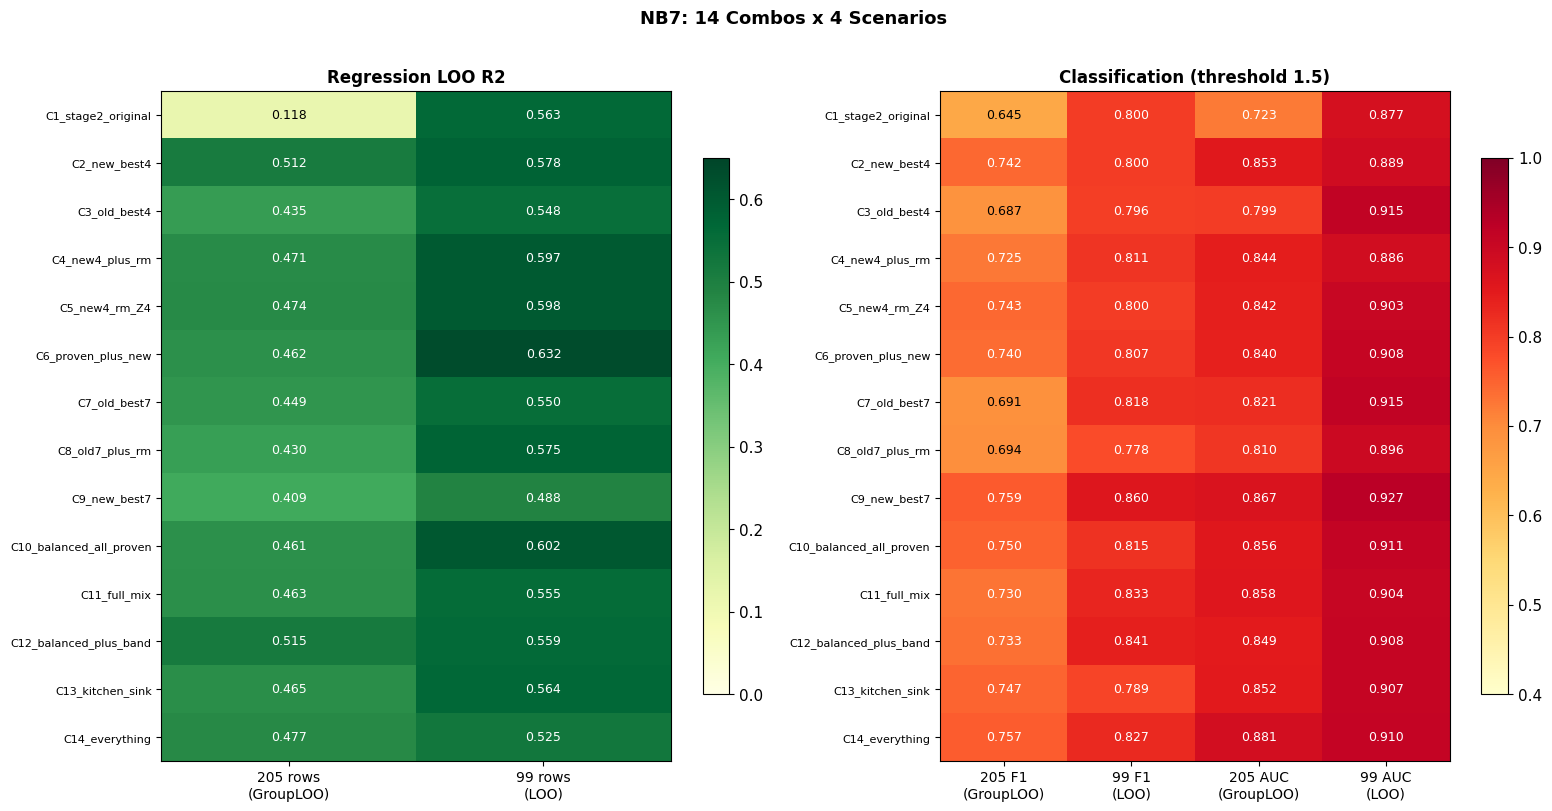

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(results_df) * 0.45)))

# Regression heatmap
reg_data = results_df[['combo', 'reg205_r2', 'reg99_r2']].set_index('combo')
reg_data.columns = ['205 rows\n(GroupLOO)', '99 rows\n(LOO)']

ax = axes[0]
im = ax.imshow(reg_data.values, cmap='YlGn', aspect='auto', vmin=0, vmax=0.65)
ax.set_xticks(range(len(reg_data.columns)))
ax.set_xticklabels(reg_data.columns, fontsize=10)
ax.set_yticks(range(len(reg_data.index)))
ax.set_yticklabels(reg_data.index, fontsize=8)
ax.set_title('Regression LOO R2', fontsize=12, fontweight='bold')
for i in range(len(reg_data.index)):
    for j in range(len(reg_data.columns)):
        val = reg_data.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.4 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im, ax=ax, shrink=0.8)

# Classification heatmap
clf_data = results_df[['combo', 'clf205_f1', 'clf99_f1', 'clf205_auc', 'clf99_auc']].set_index('combo')
clf_data.columns = ['205 F1\n(GroupLOO)', '99 F1\n(LOO)', '205 AUC\n(GroupLOO)', '99 AUC\n(LOO)']

ax = axes[1]
im2 = ax.imshow(clf_data.values, cmap='YlOrRd', aspect='auto', vmin=0.4, vmax=1.0)
ax.set_xticks(range(len(clf_data.columns)))
ax.set_xticklabels(clf_data.columns, fontsize=10)
ax.set_yticks(range(len(clf_data.index)))
ax.set_yticklabels(clf_data.index, fontsize=8)
ax.set_title('Classification (threshold 1.5)', fontsize=12, fontweight='bold')
for i in range(len(clf_data.index)):
    for j in range(len(clf_data.columns)):
        val = clf_data.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.7 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im2, ax=ax, shrink=0.8)

plt.suptitle(f'NB7: {len(results_df)} Combos x 4 Scenarios', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "heatmap_all.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 11: Multi-model test on top 5 combos (99 rows)

In [11]:
MODELS = {
    'XGBoost': XGBRegressor(**XGB_REG_PARAMS),
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'GradBoosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    'SVR_RBF': Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf', C=10, gamma='scale'))]),
}

top5 = results_df.nlargest(5, 'reg99_r2')

print("=" * 80)
print("  MULTI-MODEL REGRESSION ON 99 ROWS (LOO)")
print("=" * 80)

multi_results = []

for _, row in top5.iterrows():
    name = row['combo']
    feats_205 = [f.strip() for f in row['features'].split(',')]
    feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))

    missing = [f for f in feats_99 if f not in df_99.columns]
    if missing:
        print(f"\n  SKIP {name}: missing {missing}")
        continue

    X = df_99[feats_99].fillna(0).values
    print(f"\n  {name} ({len(feats_99)} feat):")

    for model_name, model in MODELS.items():
        try:
            y_pred = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
            r2 = r2_score(y_99, y_pred)
            mae = mean_absolute_error(y_99, y_pred)
            multi_results.append({'combo': name, 'model': model_name, 'n_feat': len(feats_99),
                                  'loo_r2': r2, 'loo_mae': mae})
            print(f"    {model_name:15s}: R2={r2:.4f}, MAE={mae:.4f}")
        except Exception as e:
            print(f"    {model_name:15s}: ERROR {e}")

multi_df = pd.DataFrame(multi_results)
multi_df.to_csv(os.path.join(RESULTS_DIR, "multi_model_results.csv"), index=False)

print(f"\n  Best per combo:")
for name in top5['combo']:
    subset = multi_df[multi_df['combo'] == name]
    if len(subset) == 0:
        continue
    best = subset.loc[subset['loo_r2'].idxmax()]
    print(f"    {best['combo']:<30s} {best['model']:<15s} R2={best['loo_r2']:.4f}")

  MULTI-MODEL REGRESSION ON 99 ROWS (LOO)

  C6_proven_plus_new (7 feat):
    XGBoost        : R2=0.6320, MAE=0.4284
    RandomForest   : R2=0.5070, MAE=0.4901
    GradBoosting   : R2=0.5322, MAE=0.4607
    SVR_RBF        : R2=0.3618, MAE=0.5283

  C10_balanced_all_proven (9 feat):
    XGBoost        : R2=0.6021, MAE=0.4228
    RandomForest   : R2=0.4939, MAE=0.4908
    GradBoosting   : R2=0.5609, MAE=0.4532
    SVR_RBF        : R2=0.2957, MAE=0.5361

  C5_new4_rm_Z4 (7 feat):
    XGBoost        : R2=0.5979, MAE=0.4385
    RandomForest   : R2=0.5089, MAE=0.4886
    GradBoosting   : R2=0.5307, MAE=0.4615
    SVR_RBF        : R2=0.3618, MAE=0.5283

  C4_new4_plus_rm (6 feat):
    XGBoost        : R2=0.5970, MAE=0.4522
    RandomForest   : R2=0.5146, MAE=0.4866
    GradBoosting   : R2=0.5627, MAE=0.4517
    SVR_RBF        : R2=0.4275, MAE=0.4908

  C2_new_best4 (5 feat):
    XGBoost        : R2=0.5778, MAE=0.4525
    RandomForest   : R2=0.4962, MAE=0.4874
    GradBoosting   : R2=0.5499, M

## Cell 12: Feature correlation heatmap

  FEATURE CORRELATION HEATMAP


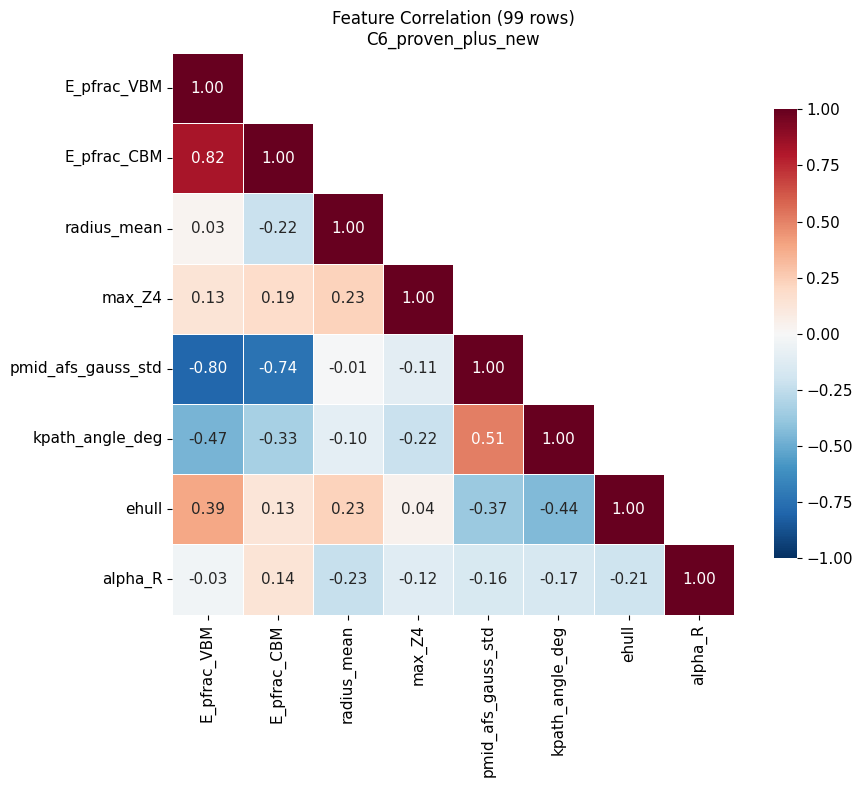

Correlation with alpha_R:
  radius_mean              : r = -0.228
  ehull                    : r = -0.208
  kpath_angle_deg          : r = -0.167
  pmid_afs_gauss_std       : r = -0.157
  E_pfrac_CBM              : r = +0.136
  max_Z4                   : r = -0.118
  E_pfrac_VBM              : r = -0.034


In [12]:
print("=" * 80)
print("  FEATURE CORRELATION HEATMAP")
print("=" * 80)

# Use features from the best 99-row combo
best_99 = results_df.loc[results_df['reg99_r2'].idxmax()]
best_feats_205 = [f.strip() for f in best_99['features'].split(',')]
best_feats_99 = swap_epfrac_for_99(best_feats_205, set(df_99.columns))

# Short names for display
def short_name(col):
    return col.replace('old_', '').replace('new_', '')

# 99-row correlation
avail_99 = [f for f in best_feats_99 if f in df_99.columns]
corr_data = df_99[avail_99 + [TARGET]].copy()
corr_data.columns = [short_name(c) for c in avail_99] + ['alpha_R']
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.zeros_like(corr_matrix)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, mask=mask, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title(f'Feature Correlation (99 rows)\n{best_99["combo"]}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "correlation_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with alpha_R:")
target_corr = corr_matrix['alpha_R'].drop('alpha_R').sort_values(key=abs, ascending=False)
for feat, corr in target_corr.items():
    print(f"  {feat:25s}: r = {corr:+.3f}")

## Cell 13: Predicted vs Actual (best combos)

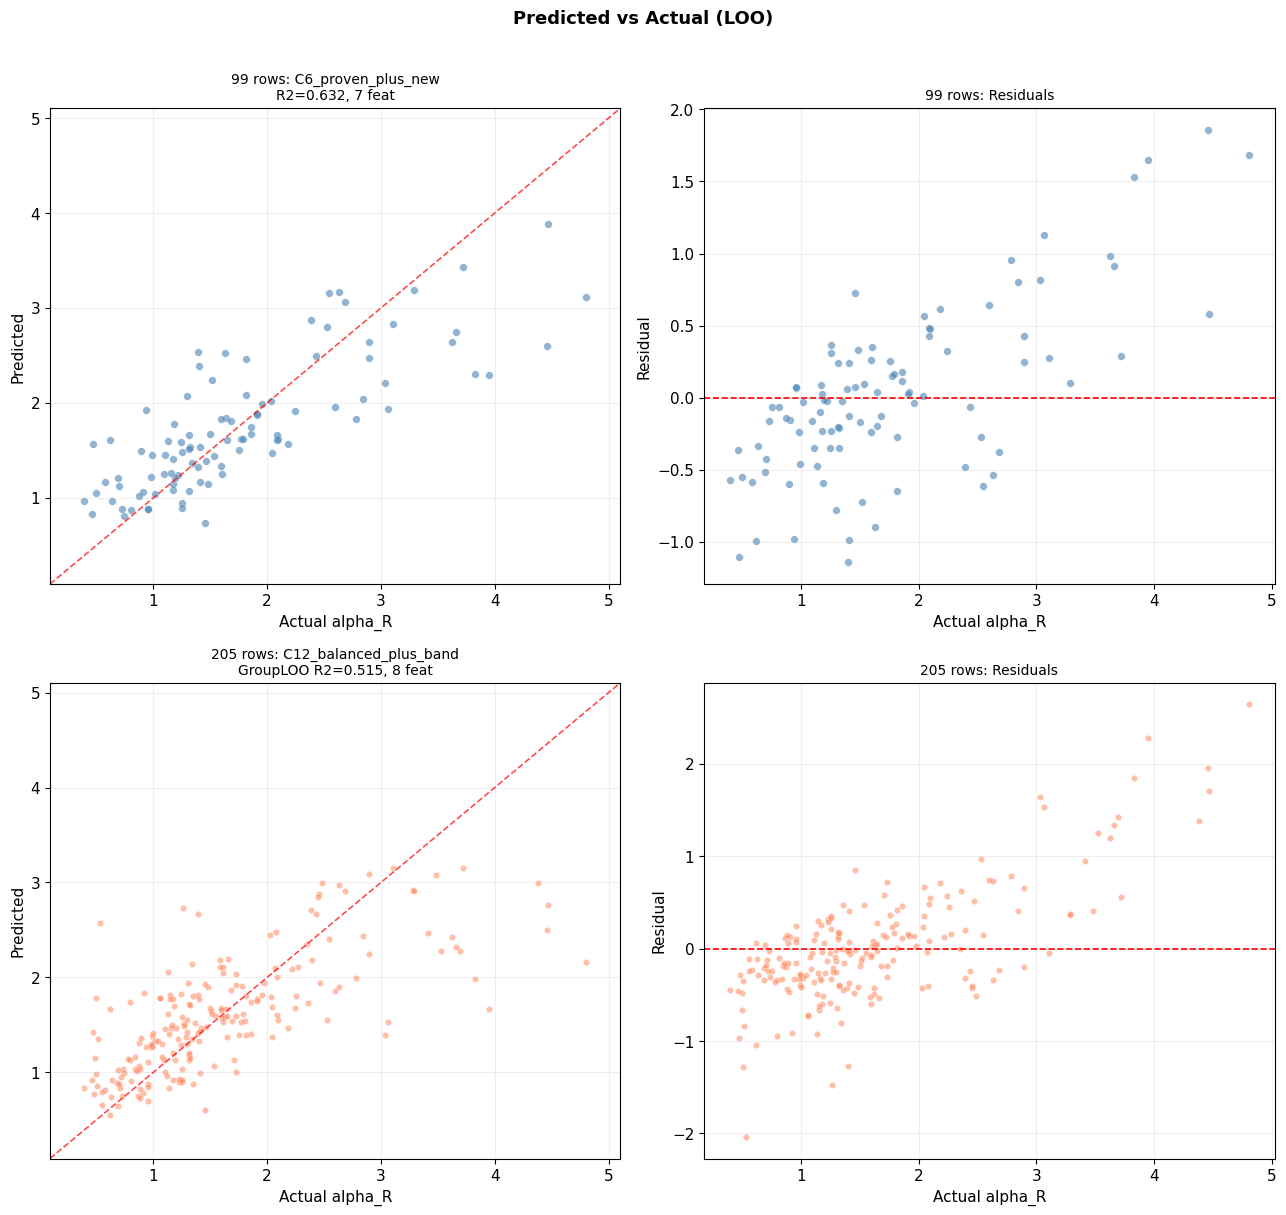

In [13]:
best_reg99 = results_df.loc[results_df['reg99_r2'].idxmax()]
best_reg205 = results_df.loc[results_df['reg205_r2'].idxmax()]

fig, axes = plt.subplots(2, 2, figsize=(13, 12))

# --- 99 rows best ---
feats_205 = [f.strip() for f in best_reg99['features'].split(',')]
feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
X = df_99[feats_99].fillna(0).values
model = XGBRegressor(**XGB_REG_PARAMS)
y_pred_99 = cross_val_predict(model, X, y_99, cv=LeaveOneOut())
r2_99_val = r2_score(y_99, y_pred_99)

ax = axes[0, 0]
ax.scatter(y_99, y_pred_99, alpha=0.6, s=30, color='steelblue', edgecolor='white', lw=0.3)
lims = [min(y_99.min(), y_pred_99.min()) - 0.3, max(y_99.max(), y_pred_99.max()) + 0.3]
ax.plot(lims, lims, 'r--', lw=1.2, alpha=0.7)
ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Predicted')
ax.set_title(f'99 rows: {best_reg99["combo"]}\nR2={r2_99_val:.3f}, {len(feats_99)} feat', fontsize=10)
ax.set_xlim(lims); ax.set_ylim(lims); ax.grid(True, alpha=0.2)

# 99 rows residuals
ax = axes[0, 1]
ax.scatter(y_99, y_99 - y_pred_99, alpha=0.6, s=30, color='steelblue', edgecolor='white', lw=0.3)
ax.axhline(y=0, color='red', linestyle='--', lw=1.2)
ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Residual')
ax.set_title('99 rows: Residuals', fontsize=10); ax.grid(True, alpha=0.2)

# --- 205 rows best ---
feats_205_b = [f.strip() for f in best_reg205['features'].split(',')]
X = df_merged[feats_205_b].fillna(0).values
model = XGBRegressor(**XGB_REG_PARAMS)
y_pred_205 = cross_val_predict(model, X, y_205, cv=LeaveOneGroupOut(), groups=groups_205)
r2_205_val = r2_score(y_205, y_pred_205)

ax = axes[1, 0]
ax.scatter(y_205, y_pred_205, alpha=0.5, s=20, color='coral', edgecolor='white', lw=0.3)
lims2 = [min(y_205.min(), y_pred_205.min()) - 0.3, max(y_205.max(), y_pred_205.max()) + 0.3]
ax.plot(lims2, lims2, 'r--', lw=1.2, alpha=0.7)
ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Predicted')
ax.set_title(f'205 rows: {best_reg205["combo"]}\nGroupLOO R2={r2_205_val:.3f}, {len(feats_205_b)} feat', fontsize=10)
ax.set_xlim(lims2); ax.set_ylim(lims2); ax.grid(True, alpha=0.2)

# 205 rows residuals
ax = axes[1, 1]
ax.scatter(y_205, y_205 - y_pred_205, alpha=0.5, s=20, color='coral', edgecolor='white', lw=0.3)
ax.axhline(y=0, color='red', linestyle='--', lw=1.2)
ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Residual')
ax.set_title('205 rows: Residuals', fontsize=10); ax.grid(True, alpha=0.2)

plt.suptitle('Predicted vs Actual (LOO)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pred_vs_actual.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 14: Feature importance for top 3 combos

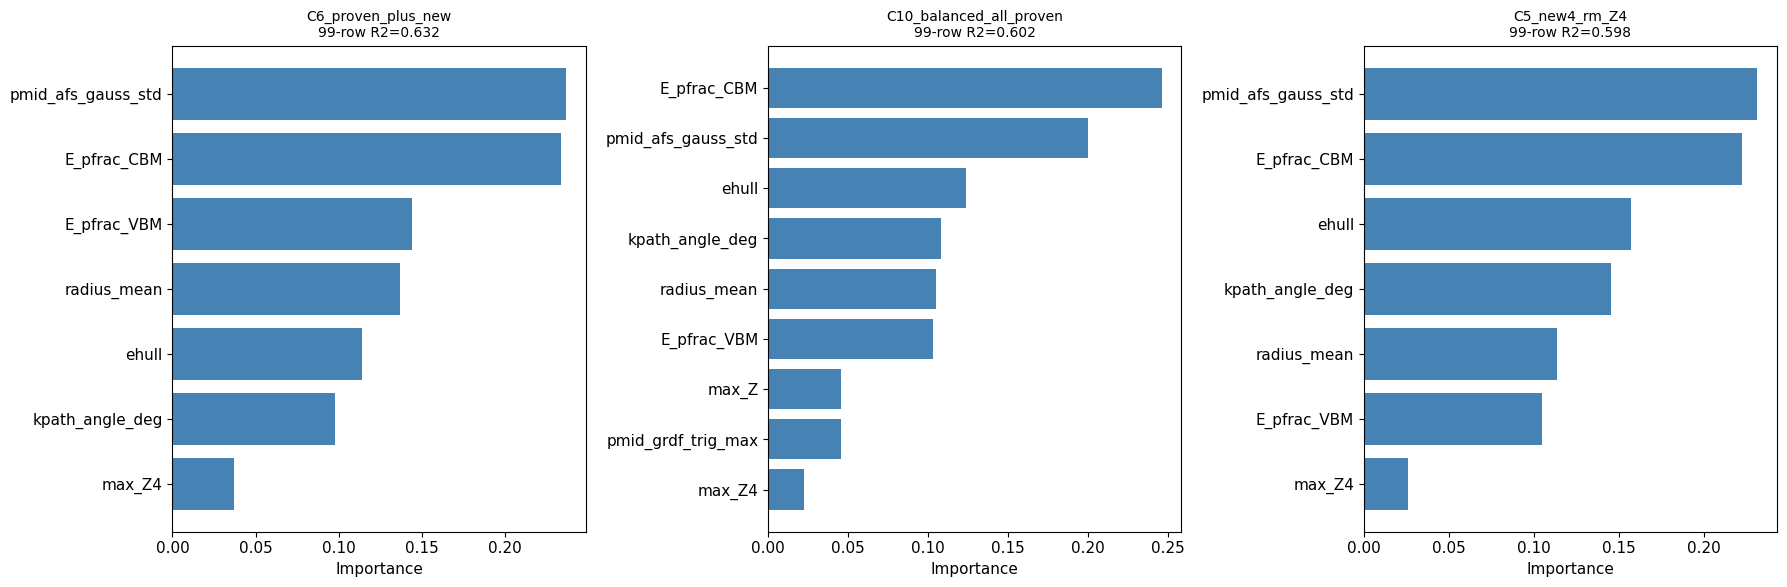

In [14]:
top3 = results_df.nlargest(3, 'reg99_r2')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (_, row) in enumerate(top3.iterrows()):
    feats_205 = [f.strip() for f in row['features'].split(',')]
    feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
    avail = [f for f in feats_99 if f in df_99.columns]

    X = df_99[avail].fillna(0).values
    model = XGBRegressor(**XGB_REG_PARAMS)
    model.fit(X, y_99)

    imp = model.feature_importances_
    labels = [short_name(f) for f in avail]
    imp_df = pd.DataFrame({'feature': labels, 'importance': imp}).sort_values('importance', ascending=True)

    ax = axes[idx]
    ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title(f"{row['combo']}\n99-row R2={row['reg99_r2']:.3f}", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_importance_top3.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 15: R2 / F1 vs feature count

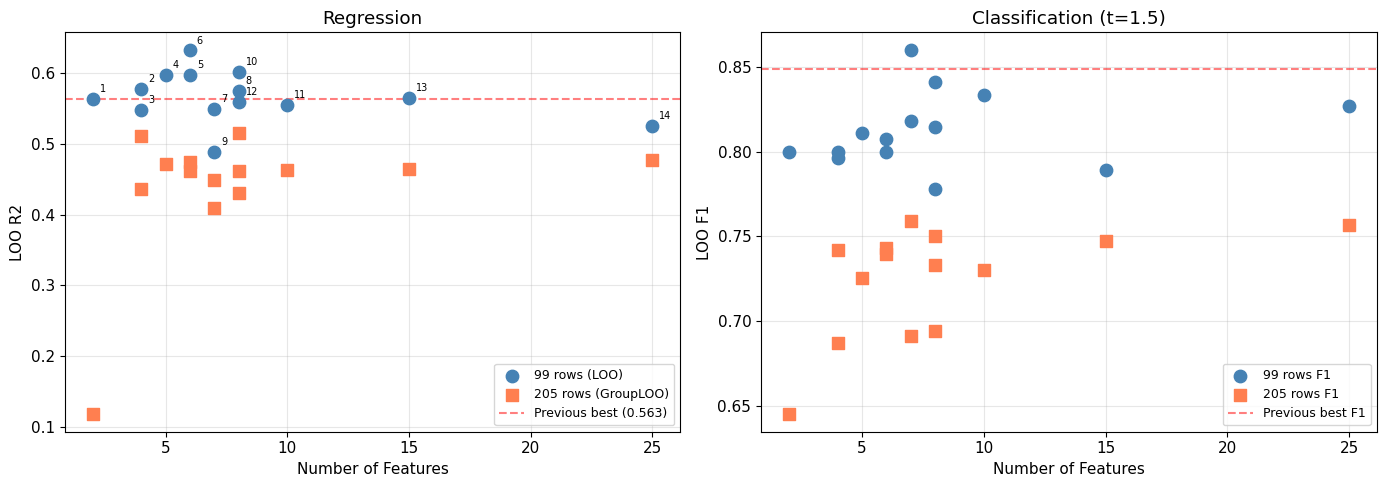

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(results_df['n_feat'], results_df['reg99_r2'], s=80, color='steelblue', label='99 rows (LOO)', zorder=3)
ax.scatter(results_df['n_feat'], results_df['reg205_r2'], s=80, color='coral', marker='s', label='205 rows (GroupLOO)', zorder=3)
ax.axhline(y=0.563, color='red', linestyle='--', alpha=0.5, label='Previous best (0.563)')
ax.set_xlabel('Number of Features'); ax.set_ylabel('LOO R2'); ax.set_title('Regression')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
for _, row in results_df.iterrows():
    ax.annotate(row['combo'].replace('C', '').split('_')[0], (row['n_feat'], row['reg99_r2']),
                textcoords="offset points", xytext=(5, 5), fontsize=7)

ax = axes[1]
ax.scatter(results_df['n_feat'], results_df['clf99_f1'], s=80, color='steelblue', label='99 rows F1', zorder=3)
ax.scatter(results_df['n_feat'], results_df['clf205_f1'], s=80, color='coral', marker='s', label='205 rows F1', zorder=3)
ax.axhline(y=0.849, color='red', linestyle='--', alpha=0.5, label='Previous best F1')
ax.set_xlabel('Number of Features'); ax.set_ylabel('LOO F1'); ax.set_title('Classification (t=1.5)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "scatter_nfeat.png"), dpi=150, bbox_inches='tight')
plt.show()

## Cell 16: Save CSVs

In [16]:
df_merged.to_csv(os.path.join(RESULTS_DIR, "merged_old_new_205.csv"), index=False)
df_99.to_csv(os.path.join(RESULTS_DIR, "merged_old_new_99.csv"), index=False)
print(f"Saved merged CSVs to {RESULTS_DIR}/")

Saved merged CSVs to .\nb7_combined-results/


## Cell 17: Final summary

In [17]:
print("=" * 80)
print("  NB7 COMPLETE -- FINAL SUMMARY")
print("=" * 80)

best_r99 = results_df.loc[results_df['reg99_r2'].idxmax()]
best_r205 = results_df.loc[results_df['reg205_r2'].idxmax()]
best_c99 = results_df.loc[results_df['clf99_f1'].idxmax()]
best_c205 = results_df.loc[results_df['clf205_f1'].idxmax()]

print(f"""
  {len(RESOLVED_COMBOS)} feature combos x 4 scenarios = {len(RESOLVED_COMBOS)*4} evaluations

  REGRESSION:
    99 rows (LOO):       {best_r99['combo']} -> R2 = {best_r99['reg99_r2']:.4f} ({int(best_r99.get('n_feat_99', best_r99['n_feat']))} feat)
    205 rows (GroupLOO):  {best_r205['combo']} -> R2 = {best_r205['reg205_r2']:.4f} ({best_r205['n_feat']} feat)
    Previous best:       R2 = 0.563 (3 feat)

  CLASSIFICATION (threshold 1.5):
    99 rows (LOO):       {best_c99['combo']} -> F1 = {best_c99['clf99_f1']:.4f}, AUC = {best_c99['clf99_auc']:.4f}
    205 rows (GroupLOO):  {best_c205['combo']} -> F1 = {best_c205['clf205_f1']:.4f}, AUC = {best_c205['clf205_auc']:.4f}
    Previous best:       F1 = 0.849, AUC = 0.907 (5 feat)

  KEY FEATURES:
    E_pfrac_VBM/CBM:     DOS p-orbital fraction at band edges (proven, Stages 1-2)
    radius_mean:          Mean atomic radius (+0.02 R2 boost consistently)
    max_Z4:               Z^4 of heaviest element (SOC coupling constant)
    pmid_afs_gauss_std:   Angular symmetry at midpoint k-plane (new, plane-based)
    pmid_grdf_trig_max:   Radial distribution at midpoint k-plane (new)
    kpath_angle_deg:      K-path direction in BZ (geometry)
    ehull:                Thermodynamic stability
""")

  NB7 COMPLETE -- FINAL SUMMARY

  14 feature combos x 4 scenarios = 56 evaluations

  REGRESSION:
    99 rows (LOO):       C6_proven_plus_new -> R2 = 0.6320 (7 feat)
    205 rows (GroupLOO):  C12_balanced_plus_band -> R2 = 0.5151 (8 feat)
    Previous best:       R2 = 0.563 (3 feat)

  CLASSIFICATION (threshold 1.5):
    99 rows (LOO):       C9_new_best7 -> F1 = 0.8598, AUC = 0.9269
    205 rows (GroupLOO):  C9_new_best7 -> F1 = 0.7590, AUC = 0.8670
    Previous best:       F1 = 0.849, AUC = 0.907 (5 feat)

  KEY FEATURES:
    E_pfrac_VBM/CBM:     DOS p-orbital fraction at band edges (proven, Stages 1-2)
    radius_mean:          Mean atomic radius (+0.02 R2 boost consistently)
    max_Z4:               Z^4 of heaviest element (SOC coupling constant)
    pmid_afs_gauss_std:   Angular symmetry at midpoint k-plane (new, plane-based)
    pmid_grdf_trig_max:   Radial distribution at midpoint k-plane (new)
    kpath_angle_deg:      K-path direction in BZ (geometry)
    ehull:              

  TWO-STAGE HURDLE MODEL (99 rows, LOO)

  C6_proven_plus_new (7 feat):
    Stage 1 classifier: F1=0.807, Acc=0.788
    Single-stage:  R2=0.6320, MAE=0.4284
    Two-stage:     R2=0.3637, MAE=0.5349  (delta=-0.2683)
    Strong class:  single R2=0.383 -> hurdle R2=0.020
    Weak class:    single R2=-1.361 -> hurdle R2=-3.796

  C5_new4_rm_Z4 (7 feat):
    Stage 1 classifier: F1=0.800, Acc=0.778
    Single-stage:  R2=0.5979, MAE=0.4385
    Two-stage:     R2=0.3553, MAE=0.5401  (delta=-0.2426)
    Strong class:  single R2=0.338 -> hurdle R2=0.028
    Weak class:    single R2=-1.682 -> hurdle R2=-4.033

  C10_balanced_all (9 feat):
    Stage 1 classifier: F1=0.815, Acc=0.798
    Single-stage:  R2=0.6021, MAE=0.4228
    Two-stage:     R2=0.3883, MAE=0.5250  (delta=-0.2138)
    Strong class:  single R2=0.354 -> hurdle R2=0.050
    Weak class:    single R2=-1.727 -> hurdle R2=-3.549

  HURDLE MODEL SUMMARY

  Combo                     #feat  Single R2  Hurdle R2    Delta
  --------------------

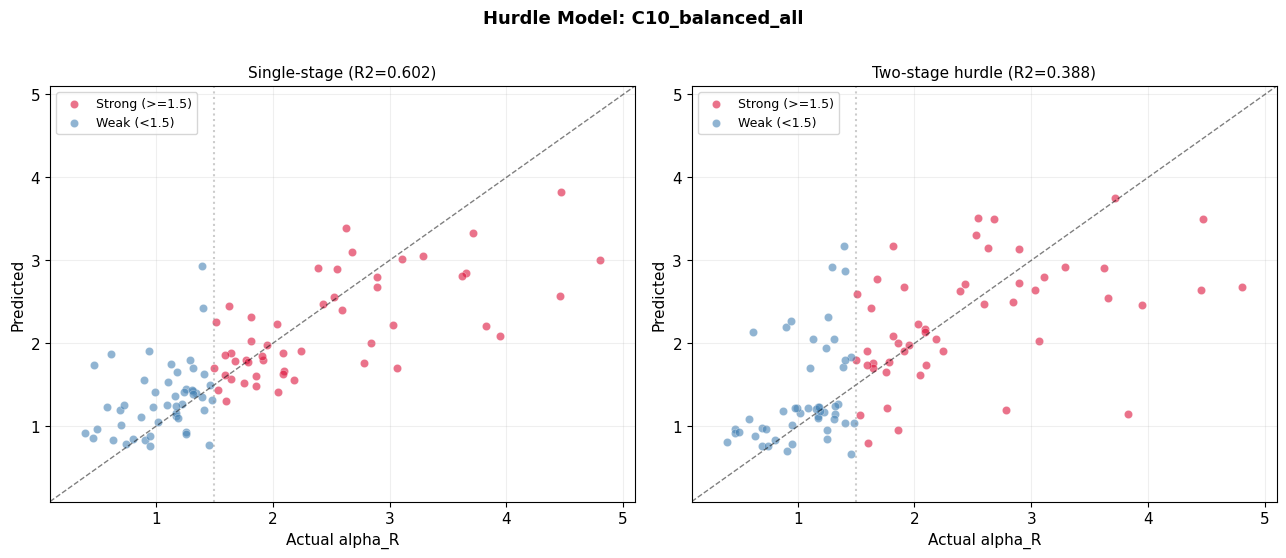

In [18]:
# %% [markdown]
# ## Cell 18: Two-Stage Hurdle Model
#
# Stage 1: Classify strong (>=1.5) vs weak (<1.5) Rashba
# Stage 2: Train separate XGBoost regressors for each class
# Evaluate end-to-end with LOO on 99 rows.

# %%
print("=" * 80)
print("  TWO-STAGE HURDLE MODEL (99 rows, LOO)")
print("=" * 80)

# Combos to test (top 3 from regression + the best classifier combo)
HURDLE_COMBOS = {
    "C6_proven_plus_new": resolve_features([
        "E_pfrac_relevant", "radius_mean", "max_Z4",
        "pmid_afs_gauss_std", "kpath_angle_deg", "ehull",
    ]),
    "C5_new4_rm_Z4": resolve_features([
        "E_pfrac_relevant", "ehull", "pmid_afs_gauss_std", "kpath_angle_deg",
        "radius_mean", "max_Z4",
    ]),
    "C10_balanced_all": resolve_features([
        "E_pfrac_relevant", "radius_mean", "max_Z4", "max_Z",
        "pmid_afs_gauss_std", "pmid_grdf_trig_max", "kpath_angle_deg", "ehull",
    ]),
}

THRESHOLD = 1.5
hurdle_results = []

for combo_name, feats_205 in HURDLE_COMBOS.items():
    feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
    missing = [f for f in feats_99 if f not in df_99.columns]
    if missing:
        print(f"\n  SKIP {combo_name}: missing {missing}")
        continue

    X = df_99[feats_99].fillna(0).values
    y_true = y_99.copy()
    y_class_true = (y_true >= THRESHOLD).astype(int)

    n = len(y_true)
    y_pred_hurdle = np.zeros(n)
    y_pred_class = np.zeros(n, dtype=int)
    y_pred_single = np.zeros(n)  # single-stage regression for comparison

    for i in range(n):
        # LOO split
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y_true, i)
        y_class_train = np.delete(y_class_true, i)
        X_test = X[i:i+1]

        # --- Single-stage regression (baseline) ---
        reg_single = XGBRegressor(**XGB_REG_PARAMS)
        reg_single.fit(X_train, y_train)
        y_pred_single[i] = reg_single.predict(X_test)[0]

        # --- Stage 1: Classification ---
        clf = XGBClassifier(**XGB_CLF_PARAMS)
        clf.fit(X_train, y_class_train)
        pred_class = clf.predict(X_test)[0]
        y_pred_class[i] = pred_class

        # --- Stage 2: Class-specific regression ---
        if pred_class == 1:  # predicted strong
            mask = y_class_train == 1
        else:  # predicted weak
            mask = y_class_train == 0

        X_class = X_train[mask]
        y_class_reg = y_train[mask]

        if len(X_class) < 5:
            # Too few samples in class, fall back to full regression
            reg = XGBRegressor(**XGB_REG_PARAMS)
            reg.fit(X_train, y_train)
        else:
            reg = XGBRegressor(**XGB_REG_PARAMS)
            reg.fit(X_class, y_class_reg)

        y_pred_hurdle[i] = reg.predict(X_test)[0]

    # Metrics
    r2_hurdle = r2_score(y_true, y_pred_hurdle)
    mae_hurdle = mean_absolute_error(y_true, y_pred_hurdle)
    r2_single = r2_score(y_true, y_pred_single)
    mae_single = mean_absolute_error(y_true, y_pred_single)
    clf_acc = accuracy_score(y_class_true, y_pred_class)
    clf_f1 = f1_score(y_class_true, y_pred_class)

    # R2 within each class
    strong_mask = y_class_true == 1
    weak_mask = y_class_true == 0

    r2_strong_hurdle = r2_score(y_true[strong_mask], y_pred_hurdle[strong_mask]) if strong_mask.sum() > 2 else np.nan
    r2_weak_hurdle = r2_score(y_true[weak_mask], y_pred_hurdle[weak_mask]) if weak_mask.sum() > 2 else np.nan
    r2_strong_single = r2_score(y_true[strong_mask], y_pred_single[strong_mask]) if strong_mask.sum() > 2 else np.nan
    r2_weak_single = r2_score(y_true[weak_mask], y_pred_single[weak_mask]) if weak_mask.sum() > 2 else np.nan

    hurdle_results.append({
        'combo': combo_name, 'n_feat': len(feats_99),
        'r2_single': r2_single, 'r2_hurdle': r2_hurdle,
        'mae_single': mae_single, 'mae_hurdle': mae_hurdle,
        'clf_f1': clf_f1, 'clf_acc': clf_acc,
        'r2_strong_single': r2_strong_single, 'r2_strong_hurdle': r2_strong_hurdle,
        'r2_weak_single': r2_weak_single, 'r2_weak_hurdle': r2_weak_hurdle,
    })

    delta_r2 = r2_hurdle - r2_single
    print(f"\n  {combo_name} ({len(feats_99)} feat):")
    print(f"    Stage 1 classifier: F1={clf_f1:.3f}, Acc={clf_acc:.3f}")
    print(f"    Single-stage:  R2={r2_single:.4f}, MAE={mae_single:.4f}")
    print(f"    Two-stage:     R2={r2_hurdle:.4f}, MAE={mae_hurdle:.4f}  (delta={delta_r2:+.4f})")
    print(f"    Strong class:  single R2={r2_strong_single:.3f} -> hurdle R2={r2_strong_hurdle:.3f}")
    print(f"    Weak class:    single R2={r2_weak_single:.3f} -> hurdle R2={r2_weak_hurdle:.3f}")

# Summary
print(f"\n{'='*80}")
print("  HURDLE MODEL SUMMARY")
print(f"{'='*80}")
print(f"\n  {'Combo':<25s} {'#feat':>5s} {'Single R2':>10s} {'Hurdle R2':>10s} {'Delta':>8s}")
print(f"  {'-'*62}")
for r in hurdle_results:
    delta = r['r2_hurdle'] - r['r2_single']
    print(f"  {r['combo']:<25s} {r['n_feat']:>5d} {r['r2_single']:>10.4f} {r['r2_hurdle']:>10.4f} {delta:>+8.4f}")

# Plot: pred vs actual for best combo (both single and hurdle)
best_h = max(hurdle_results, key=lambda x: x['r2_hurdle'])
best_name = best_h['combo']
feats_205 = HURDLE_COMBOS[best_name]
feats_99 = swap_epfrac_for_99(feats_205, set(df_99.columns))
X = df_99[feats_99].fillna(0).values

# Recompute predictions for plotting
y_pred_s = np.zeros(len(y_99))
y_pred_h = np.zeros(len(y_99))
for i in range(len(y_99)):
    X_tr = np.delete(X, i, axis=0)
    y_tr = np.delete(y_99, i)
    yc_tr = np.delete(y_class_99, i)
    X_te = X[i:i+1]

    reg_s = XGBRegressor(**XGB_REG_PARAMS)
    reg_s.fit(X_tr, y_tr)
    y_pred_s[i] = reg_s.predict(X_te)[0]

    clf = XGBClassifier(**XGB_CLF_PARAMS)
    clf.fit(X_tr, yc_tr)
    pc = clf.predict(X_te)[0]
    mask = yc_tr == pc
    X_c = X_tr[mask]; y_c = y_tr[mask]
    if len(X_c) < 5:
        reg_h = XGBRegressor(**XGB_REG_PARAMS)
        reg_h.fit(X_tr, y_tr)
    else:
        reg_h = XGBRegressor(**XGB_REG_PARAMS)
        reg_h.fit(X_c, y_c)
    y_pred_h[i] = reg_h.predict(X_te)[0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for idx, (label, y_p, r2_val) in enumerate([
    (f"Single-stage (R2={r2_score(y_99, y_pred_s):.3f})", y_pred_s, r2_score(y_99, y_pred_s)),
    (f"Two-stage hurdle (R2={r2_score(y_99, y_pred_h):.3f})", y_pred_h, r2_score(y_99, y_pred_h)),
]):
    ax = axes[idx]
    strong = y_class_99 == 1
    ax.scatter(y_99[strong], y_p[strong], alpha=0.6, s=35, color='crimson', label='Strong (>=1.5)', edgecolor='white', lw=0.3)
    ax.scatter(y_99[~strong], y_p[~strong], alpha=0.6, s=35, color='steelblue', label='Weak (<1.5)', edgecolor='white', lw=0.3)
    lims = [min(y_99.min(), y_p.min()) - 0.3, max(y_99.max(), y_p.max()) + 0.3]
    ax.plot(lims, lims, 'k--', lw=1, alpha=0.5)
    ax.axvline(x=1.5, color='gray', linestyle=':', alpha=0.4)
    ax.set_xlabel('Actual alpha_R'); ax.set_ylabel('Predicted')
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9); ax.set_xlim(lims); ax.set_ylim(lims); ax.grid(True, alpha=0.2)

plt.suptitle(f'Hurdle Model: {best_name}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "hurdle_model.png"), dpi=150, bbox_inches='tight')
plt.show()

hurdle_df = pd.DataFrame(hurdle_results)
hurdle_df.to_csv(os.path.join(RESULTS_DIR, "hurdle_results.csv"), index=False)